# Change path to data set here if necessary

In [1]:
DATASET_PATH = "./gesture_dataset_sample/gesture_dataset_sample/"

# Evaluation of hyperparameter: number of training images

## Approach and Assumptions

### Approach 
- Since the subset of the HaGRID Dataset on GRIPS contains 250 images per gesture, we can simply take this value as a maximum and decrease the amount of images per gesture in certain steps.
- I chose to set the step size to 25 because this allows and even distribution while creating more then 5 values for testing. 
- With a reduction of the total images used, we not only reduce the training but also the test dataset. I chose to do it this way to keep the convention of a 80/20 test split and not to keep the test set the same size. 
- With these (sub)subsets we can simply train (and test) a new model with each resulting number of images ([25, 50, 75, 100, 125, 150, 175, 200, 225, 250]) and test the training time, prediction time, accuracy etc. 
- The model used is simply provided model (already in notebook) and will not be changed during testing so changes in performance and accuracy can only be a result of the varying size of the training dataset. 
- I just excluded the stop early callback to ensure the fixed number of training epochs across all models for fair comparison of total training time between dataset sizes and to avoid early stopping (occurred with few images) 
### Assumptions
- I would assume that an increase in number of images for training boosts accuracy and reduces confusion. However training time will probably also be increased. 
- I am not sure if prediction time will also increase but it probably shouldn't since we are not adding new layers but instead are only modifying the layers during training.
- A very low number of images probably results in poor accuracy and high confusion. At some point the accuracy could become quite good and only increase little with more training data.

In [2]:
import cv2, time
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, LeakyReLU, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3


imgs_per_gesture = []
for i in range(25, 251,25): # 250 is the maximum of the dataset (per gesture) from GRIPS
    imgs_per_gesture.append(i)
imgs_per_gesture
    


[25, 50, 75, 100, 125, 150, 175, 200, 225, 250]

In [3]:
# helper function to load and parse annotations (from lecture)
annotations = dict()

for condition in CONDITIONS:
    with open(f'{DATASET_PATH}_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)


In [5]:
# helper function to pre-process images (color channel conversion and resizing) (from lecture)
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [6]:
data_subsets = []
# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for img_num in imgs_per_gesture:
    subset = {}
    subset["imgs_per_gesture"] = img_num
    
    images = [] # stores actual image data
    labels = [] # stores labels (as integer - because this is what our network needs)
    label_names = [] # maps label ints to their actual categories so we can understand predictions later

  
   
    for condition in CONDITIONS:
        
        full_path = os.path.join(DATASET_PATH, condition)
        count = 0
        
        for filename in os.listdir(full_path):
        
            if count >= img_num:
                break
                
            # extract unique ID from file name
            UID = filename.split('.')[0]
            img = cv2.imread(f'{full_path}/{filename}')
            
            # get annotation from the dict we loaded earlier
            try:
                annotation = annotations[condition][UID]
            except Exception as e:
                print(e)
                continue
            
            # iterate over all hands annotated in the image
            for i, bbox in enumerate(annotation['bboxes']):
                # annotated bounding boxes are in the range from 0 to 1
                # therefore we have to scale them to the image size
                x1 = int(bbox[0] * img.shape[1])
                y1 = int(bbox[1] * img.shape[0])
                w = int(bbox[2] * img.shape[1])
                h = int(bbox[3] * img.shape[0])
                x2 = x1 + w
                y2 = y1 + h
                
                # crop image to the bounding box and apply pre-processing
                crop = img[y1:y2, x1:x2]
                preprocessed = preprocess_image(crop)
                
                # get the annotated hand's label
                # if we have not seen this label yet, add it to the list of labels
                label = annotation['labels'][i]
                if label == "no_gesture":
                    continue
                if label not in label_names:
                    label_names.append(label)
                
                label_index = label_names.index(label)
                
                images.append(preprocessed)
                labels.append(label_index)
                
                count += 1
                    
    subset["images"] = images 
    subset["labels"] = labels 
    subset["label_names"] = label_names
    
    data_subsets.append(subset)
    
# for subset in data_subsets:
#    print(subset["imgs_per_gesture"])
#    print(len(subset["images"]))
#    print(len(subset["labels"]))
#    print(subset["label_names"])

    

## split the data sets into train and test

In [7]:

for subset in data_subsets:
    X_train, X_test, y_train, y_test = train_test_split(subset["images"], subset["labels"], test_size=0.2, random_state=42)
    subset["X_train"] = X_train
    subset["X_test"] = X_test
    subset["y_train"] = y_train
    subset["y_test"]  = y_test
    
# x is for the actual data, y is for the label (this is convention)

## transform data sets into a format compatible with our neural network

In [8]:
for subset in data_subsets:
    subset["X_train"] = np.array(subset["X_train"]).astype('float32')
    subset["X_train"] = subset["X_train"] / 255.

    subset["X_test"] = np.array(subset["X_test"]).astype('float32')
    subset["X_test"] = subset["X_test"] / 255.

    y_train_one_hot = to_categorical(subset["y_train"])
    y_test_one_hot = to_categorical(subset["y_test"])

    subset["train_label"] = y_train_one_hot
    subset["test_label"] = y_test_one_hot

    subset["X_train"] = subset["X_train"].reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
    subset["X_test"] = subset["X_test"].reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

    #print(subset["X_train"].shape, subset["X_test"] .shape, subset["train_label"].shape, subset["test_label"] .shape)

In [9]:
# variables for hyperparameters
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'LeakyReLU'  # LeakyReLU
# I got an error with this: ValueError Could not interpret activation function identifier: LeakyReLU
# I changed the Conv2D layers so it works and added the LeakyReLU as extra layers afterwards
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
for subset in data_subsets:
    model = Sequential()

    # data augmentation (this can also be done beforehand - but don't augment the test dataset!)
    model.add(RandomFlip('horizontal'))
    model.add(RandomContrast(0.1))
    #model.add(RandomBrightness(0.1))
    #model.add(RandomRotation(0.2))

    # first, we add some convolution layers followed by max pooling
    model.add(Conv2D(64, kernel_size=(9, 9), input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
    model.add(LeakyReLU())
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    model.add(Conv2D(32, (5, 5), padding='same'))
    model.add(LeakyReLU())
    
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

    model.add(Conv2D(32, (3, 3), padding='same'))
    model.add(LeakyReLU())
    
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    # dropout layers can drop part of the data during each epoch - this prevents overfitting
    model.add(Dropout(0.2))

    # after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
    model.add(Flatten())

    # add some fully connected layers ("Dense")
    for i in range(layer_count - 1):
        model.add(Dense(num_neurons, activation=activation))

    model.add(Dense(num_neurons, activation=activation))

    # for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
    model.add(Dense(num_classes, activation='softmax'))

    # specify loss function, optimizer and evaluation metrics
    # for classification, categorial crossentropy is used as a loss function
    # use the adam optimizer unless you have a good reason not to
    model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])
    
    subset["model"] = model

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
# stop_early = EarlyStopping(monitor='val_loss', patience=3)

c:\Users\mozet\ITT\assignment-05-cnn-marcel-moz\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## now, we train the models 

In [ ]:
for subset in data_subsets:
    start_time = time.time()
    history = subset["model"].fit(
        subset["X_train"],
        subset["train_label"],
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(subset["X_test"], subset["test_label"]),
        callbacks=[reduce_lr]
    )
    duration = time.time() - start_time
    subset["training_time"] = round(duration, 3)
    subset["history"] = history.history


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6250 - loss: 0.6912 - val_accuracy: 0.3000 - val_loss: 0.9981 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5500 - loss: 0.7193 - val_accuracy: 0.7000 - val_loss: 0.6644 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4500 - loss: 0.7301 - val_accuracy: 0.6000 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5250 - loss: 0.7090 - val_accuracy: 0.3000 - val_loss: 0.8248 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5500 - loss: 0.6959 - val_accuracy: 0.3000 - val_loss: 0.7794 - learning_rate: 2.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5500 - loss: 0.7002 - val_accuracy: 0.3000 - val_loss: 0.7538 - learning_rate: 2.0000e-04
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5750 - loss: 0.6825 - val_accuracy:

In [ ]:
for subset in data_subsets:
    # let's have a look at our model
    subset["model"].summary()
    

## Plot accuracy and loss of the training process

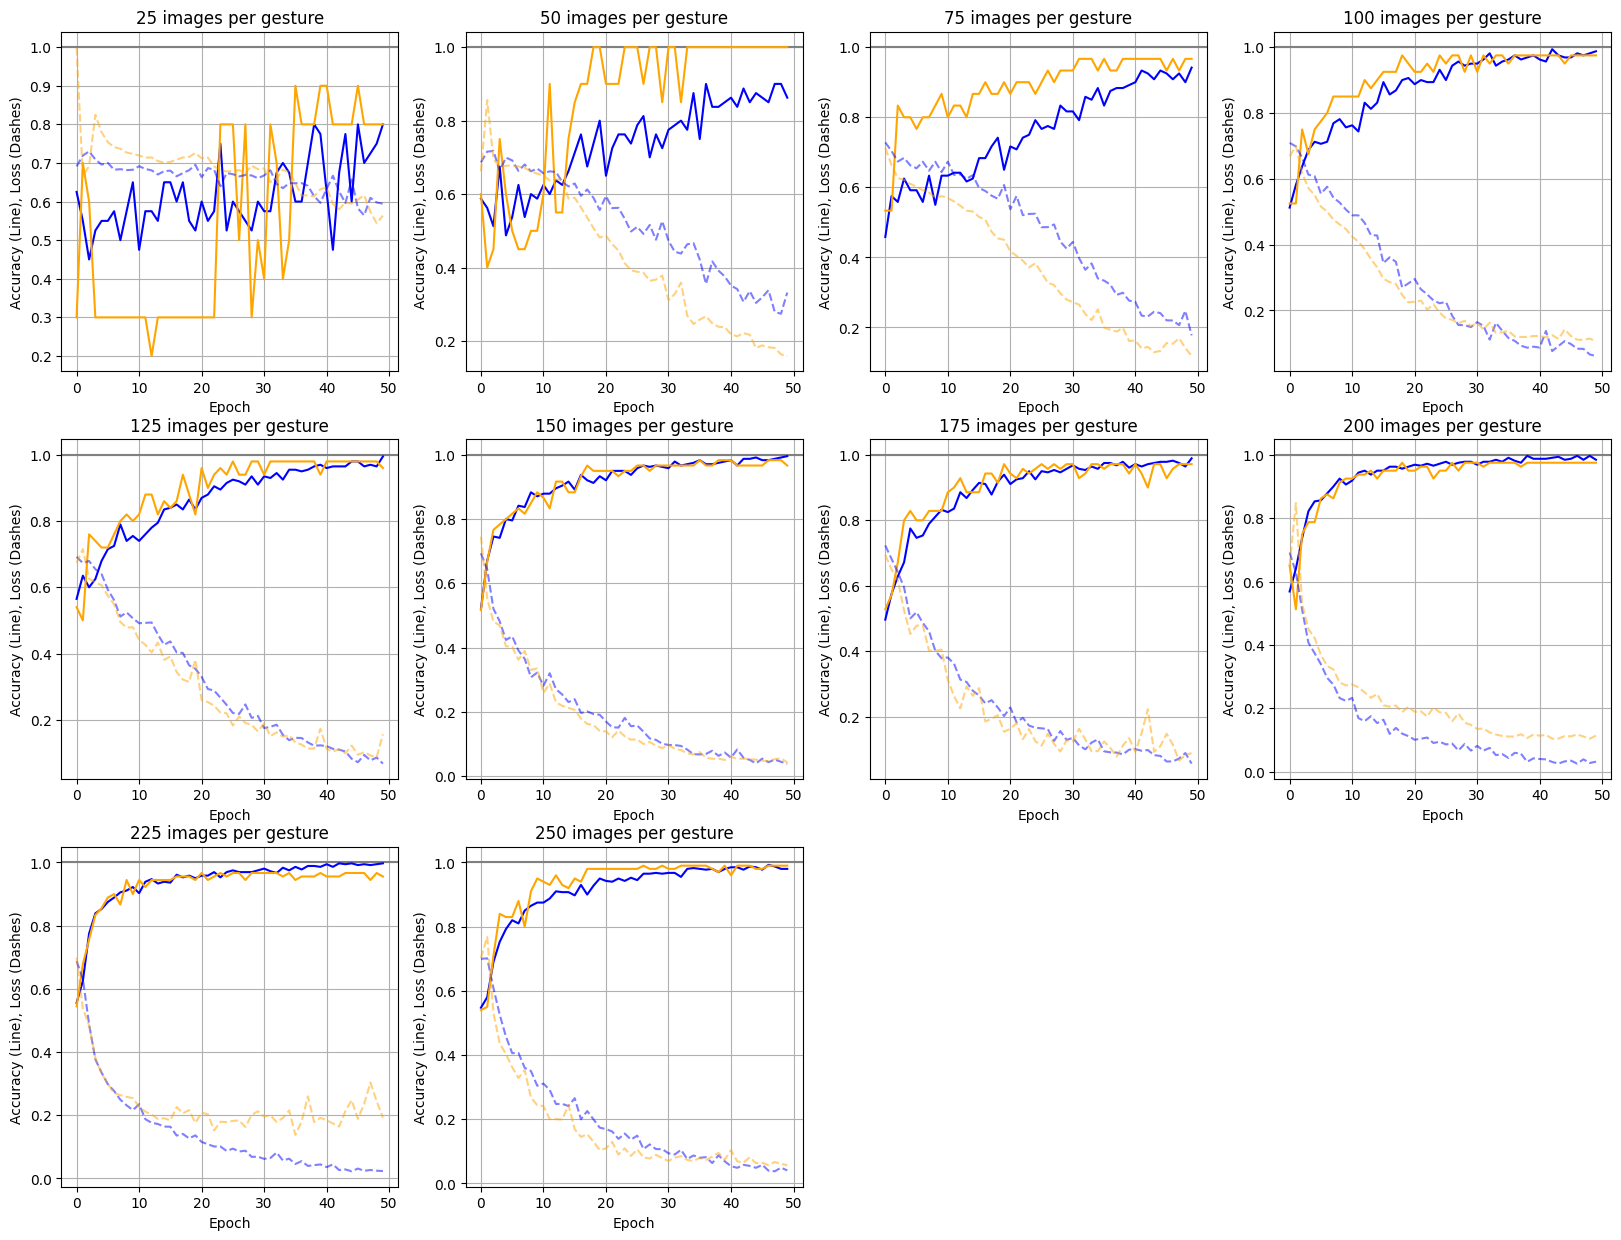

In [36]:
PLOT_PATH = f".{os.sep}plots{os.sep}"

fig = plt.figure(figsize=(20, 15))

for i, subset in enumerate(data_subsets, 1):
    loss = subset["history"]['loss']
    val_loss = subset["history"]['val_loss']
    accuracy = subset["history"]['accuracy']
    val_accuracy = subset["history"]['val_accuracy']

    
    
    plt.subplot(3, 4, i) 
    
    plt.title(f"{subset["imgs_per_gesture"]} images per gesture")
    
    ax = plt.gca()

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

    ax.axhline(1, color='gray')
     
    
    plt.plot(accuracy, color='blue')
    plt.plot(val_accuracy, color='orange')
    plt.plot(loss, '--', color='blue', alpha=0.5)
    plt.plot(val_loss, '--', color='orange', alpha=0.5)
    
    plt.grid()
    
plt.savefig(f"{PLOT_PATH}accuracy_and_loss_overview.png", dpi=300, bbox_inches="tight")

## visualize classification results with  confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


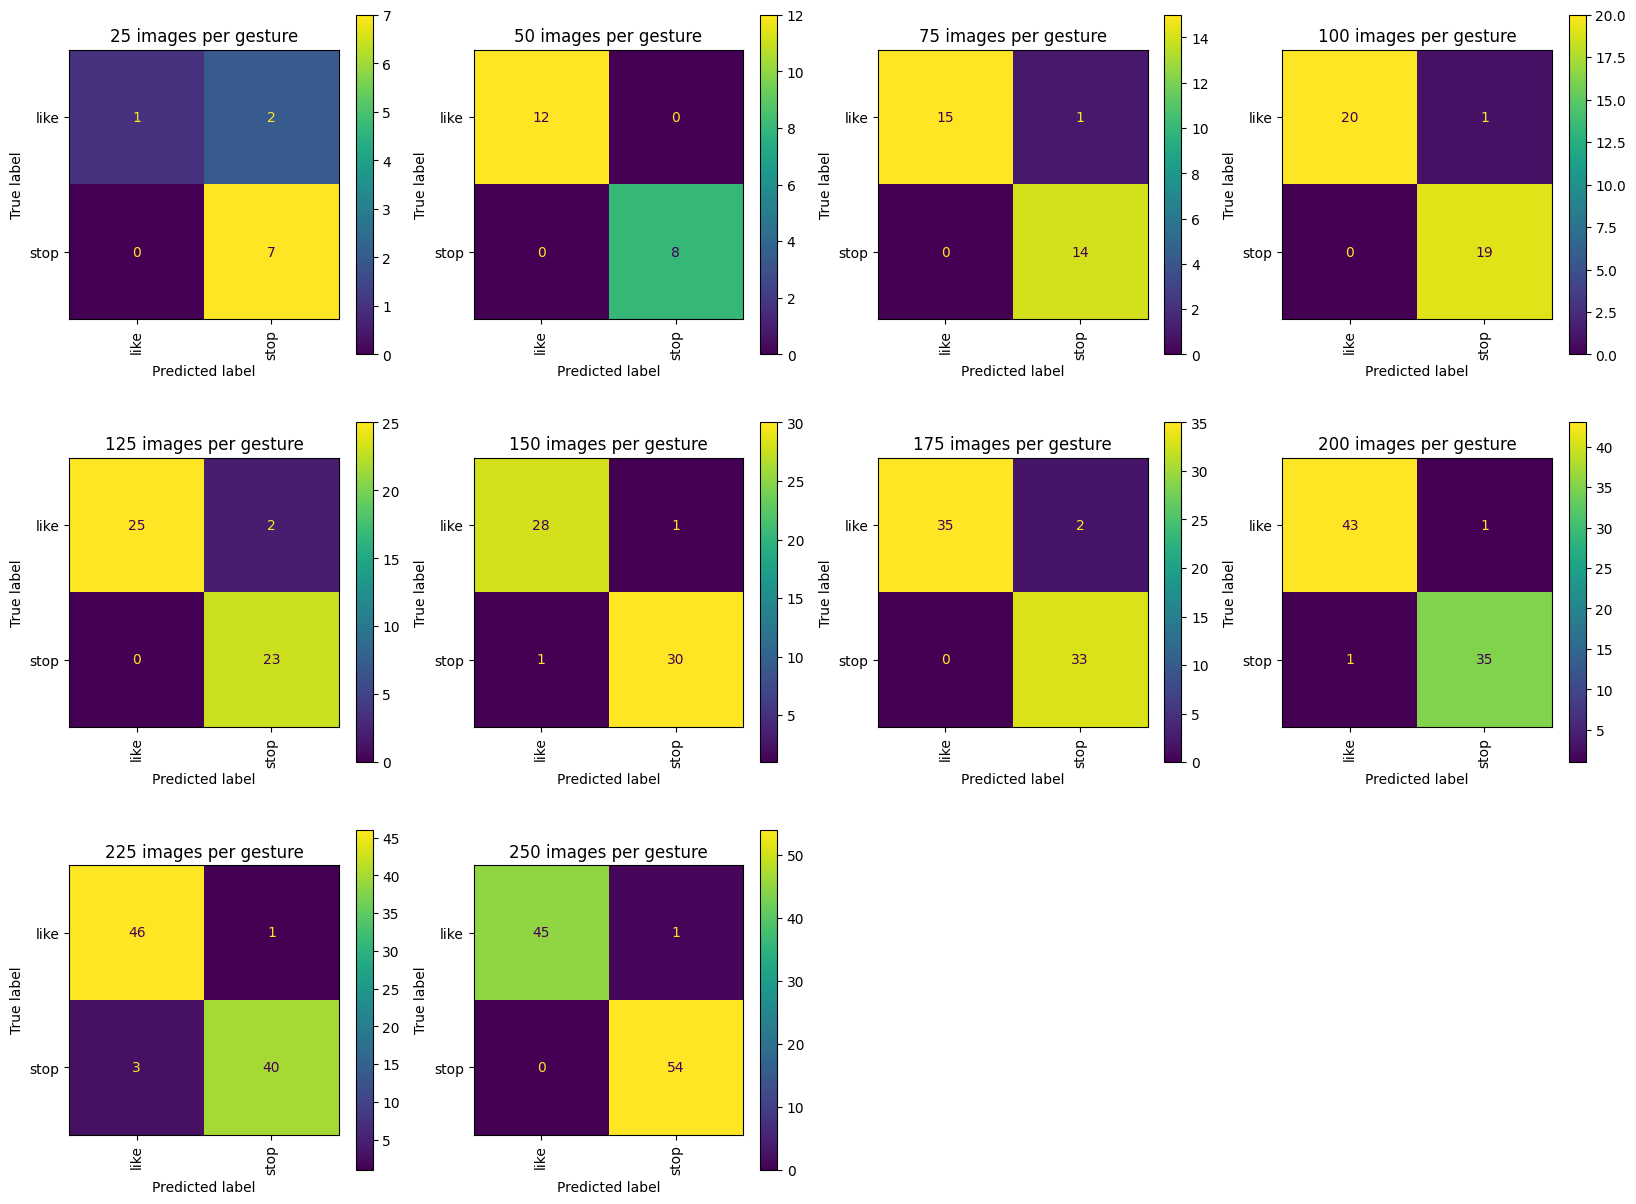

In [37]:
fig = plt.figure(figsize=(20, 15))

for i, subset in enumerate(data_subsets,1):
    # let the model make predictions for our training data
    start_time = time.time()
    y_predictions = subset["model"].predict(subset["X_test"])#
    duration = time.time() - start_time
    subset["prediction_time"] = duration / len(subset["X_test"])

    # we get a 2D numpy array with probabilities for each category
    # print('before', y_predictions)

    # to build a confusion matrix, we have to convert it to classifications
    # this can be done by using the argmax() function to set the probability to 1 and the rest to 0
    y_predictions = np.argmax(y_predictions, axis=1)

    # print('probabilities', y_predictions)

    # create and plot confusion matrix
    conf_matrix = confusion_matrix(subset["y_test"], y_predictions)
    

    

    ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.subplot(3, 4, i)  )
    plt.title(f"{subset["imgs_per_gesture"]} images per gesture")
    plt.xticks(rotation=90, ha='center')

plt.savefig(f"{PLOT_PATH}confusion_matrices.png", dpi=300, bbox_inches="tight")

In [38]:
results = []

print("# Results")
for subset in data_subsets:
    
    imgs_per_gesture = subset["imgs_per_gesture"]
    total_images = subset["imgs_per_gesture"] * len(subset["label_names"])
    train_images = len(subset["X_train"])
    test_images = len(subset["X_test"])
    total_training_time = subset["training_time"]
    prediction_time = subset["prediction_time"]
    time_per_epoch = subset["training_time"] / len(subset["history"]["loss"])
    best_accuracy = np.array(subset["history"]["val_accuracy"]).max()
    lowest_loss = np.array(subset["history"]["val_loss"]).min()
    
    accuracy_gain = np.diff(subset["history"]["val_accuracy"]) 
    
    avg_accuracy_gain_total = np.mean(accuracy_gain)
    avg_accuracy_gain_first_10_epochs = np.mean(accuracy_gain[:10])
    avg_accuracy_gain_last_10_epochs = np.mean(accuracy_gain[-10:])
    
    
    print(f"## Subset with {imgs_per_gesture} images per gesture")
    print(f"- Total images: {total_images}")
    print(f"- Train images: {train_images}")
    print(f"- Test images: {test_images}")
    print(f"- Total training time: {total_training_time}")
    print(f"- Total prediciton time: {prediction_time}")
    print(f"- Average training time per epoch: {time_per_epoch}s")
    print(f"- max val_accuracy: {best_accuracy}")
    print(f"- min val_loss: {lowest_loss}")
    
    print(f"- Average val_accuracy gain over all epochs: {avg_accuracy_gain_total}")
    print(f"- Average val_accuracy gain in the first 10 epochs: {avg_accuracy_gain_first_10_epochs}")
    print(f"- Average val_accuracy gain in the last 10 epochs: {avg_accuracy_gain_last_10_epochs}")


    results.append({
        "imgs_per_gesture" : imgs_per_gesture,
        "total_images": total_images,
        "train_images": train_images,
        "test_images": test_images,
        "total_training_time": total_training_time,
        "prediction_time": prediction_time,
        "time_per_epoch" : time_per_epoch,
        "best_accuracy": best_accuracy,
        "lowest_loss": lowest_loss,
        "avg_accuracy_gain_total": avg_accuracy_gain_total,
        "avg_accuracy_gain_first_10_epochs": avg_accuracy_gain_first_10_epochs,
        "avg_accuracy_gain_last_10_epochs": avg_accuracy_gain_last_10_epochs,

    })



# Results
## Subset with 25 images per gesture
- Total images: 50
- Train images: 40
- Test images: 10
- Total training time: 7.489
- Total prediciton time: 0.005997610092163086
- Average training time per epoch: 0.14978s
- max val_accuracy: 0.8999999761581421
- min val_loss: 0.5439344048500061
- Average val_accuracy gain over all epochs: 0.01020408163265306
- Average val_accuracy gain in the first 10 epochs: 0.0
- Average val_accuracy gain in the last 10 epochs: -0.009999996423721314
## Subset with 50 images per gesture
- Total images: 100
- Train images: 80
- Test images: 20
- Total training time: 10.242
- Total prediciton time: 0.003229570388793945
- Average training time per epoch: 0.20484000000000002s
- max val_accuracy: 1.0
- min val_loss: 0.1592622548341751
- Average val_accuracy gain over all epochs: 0.00816326481955392
- Average val_accuracy gain in the first 10 epochs: 0.0
- Average val_accuracy gain in the last 10 epochs: 0.0
## Subset with 75 images per gesture
- Total imag

# Now plot all results to compare 

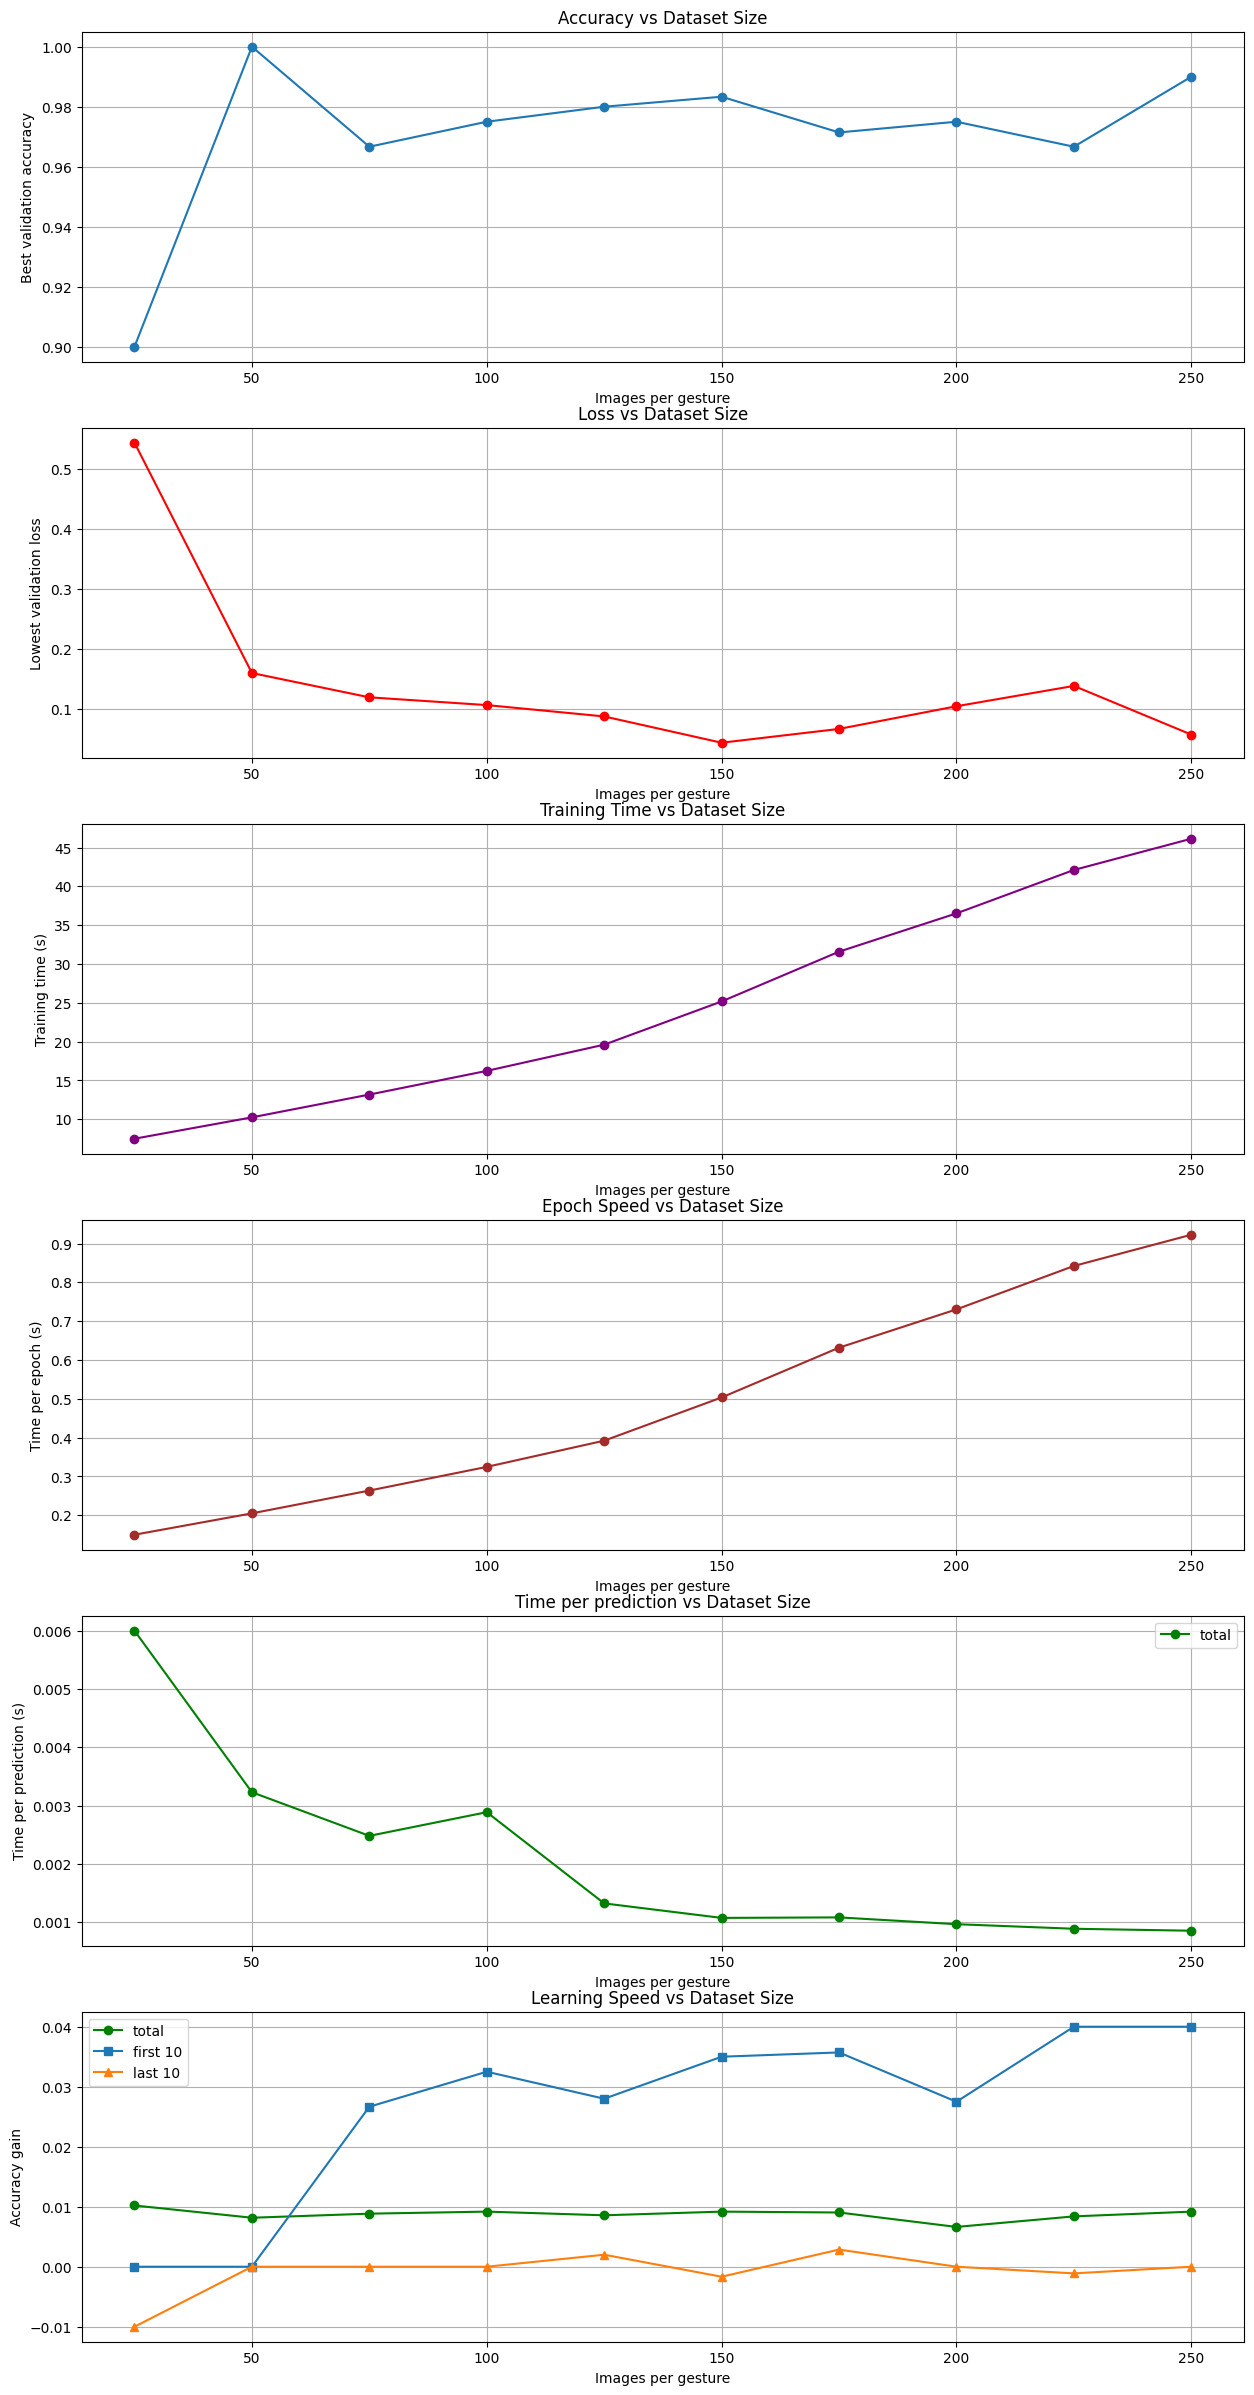

In [39]:
# this cell was generated by chat gpt because it would have been a lot to write by hand 
imgs = [r["imgs_per_gesture"] for r in results]

total_images = [r["total_images"] for r in results]
train_images = [r["train_images"] for r in results]
test_images = [r["test_images"] for r in results]

training_time = [r["total_training_time"] for r in results]
time_per_epoch = [r["time_per_epoch"] for r in results]

prediction_time = [r["prediction_time"] for r in results]

best_accuracy = [r["best_accuracy"] for r in results]
lowest_loss = [r["lowest_loss"] for r in results]

avg_gain = [r["avg_accuracy_gain_total"] for r in results]
avg_gain_first10 = [r["avg_accuracy_gain_first_10_epochs"] for r in results]
avg_gain_last10 = [r["avg_accuracy_gain_last_10_epochs"] for r in results]


plt.figure(figsize=(15,30))

plt.subplot(6, 1, 1)
plt.plot(imgs, best_accuracy, marker='o')
plt.xlabel("Images per gesture")
plt.ylabel("Best validation accuracy")
plt.title("Accuracy vs Dataset Size")
plt.grid()


plt.subplot(6, 1, 2)
plt.plot(imgs, lowest_loss, marker='o', color='red')
plt.xlabel("Images per gesture")
plt.ylabel("Lowest validation loss")
plt.title("Loss vs Dataset Size")
plt.grid()



plt.subplot(6, 1, 3)
plt.plot(imgs, training_time, marker='o', color='purple')
plt.xlabel("Images per gesture")
plt.ylabel("Training time (s)")
plt.title("Training Time vs Dataset Size")
plt.grid()


plt.subplot(6, 1, 4)
plt.plot(imgs, time_per_epoch, marker='o', color='brown')
plt.xlabel("Images per gesture")
plt.ylabel("Time per epoch (s)")
plt.title("Epoch Speed vs Dataset Size")
plt.grid()

plt.subplot(6, 1, 5)
plt.plot(imgs, prediction_time, marker='o', color='green', label="total")
plt.xlabel("Images per gesture")
plt.ylabel("Time per prediction (s)")
plt.title("Time per prediction vs Dataset Size")
plt.legend()
plt.grid()

plt.subplot(6, 1, 6)
plt.plot(imgs, avg_gain, marker='o', color='green', label="total")
plt.plot(imgs, avg_gain_first10, marker='s', label="first 10")
plt.plot(imgs, avg_gain_last10, marker='^', label="last 10")
plt.xlabel("Images per gesture")
plt.ylabel("Accuracy gain")
plt.title("Learning Speed vs Dataset Size")
plt.legend()
plt.grid()



plt.savefig(f"{PLOT_PATH}overall_comparison.png", dpi=300, bbox_inches="tight")


